# Cat/Dog Pytorch reference network

So far we've been working with fairly artificial datasets that you wouldn't typically be using in real projects. Instead, you'll likely be dealing with full-sized images like you'd get from smart phone cameras. In this notebook, we'll look at how to load images and use them to train neural networks.

We'll be using a [dataset of cat and dog photos](https://www.kaggle.com/c/dogs-vs-cats) available from Kaggle. Here are a couple example images:

<img src='./assets/dog_cat.png'>

We'll use this dataset to train a neural network that can differentiate between cats and dogs. These days it doesn't seem like a big accomplishment, but five years ago it was a serious challenge for computer vision systems.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms
import helper


## Dataloaders and transformers

In [2]:
BATCH_SIZE = 32
data_dir = "/scratch/project_2018566/data/PetImages" ## TODO: set correct path here


# TODO: Define transforms for the training data and testing data
train_transforms = transforms.Compose([transforms.RandomRotation(30),
                                       transforms.RandomResizedCrop(224),
                                       transforms.RandomHorizontalFlip(),
                                       transforms.ToTensor()])

test_transforms = transforms.Compose([transforms.Resize(255),
                                      transforms.CenterCrop(224),
                                      transforms.ToTensor()])


# Pass transforms in here, then run the next cell to see how the transforms look
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

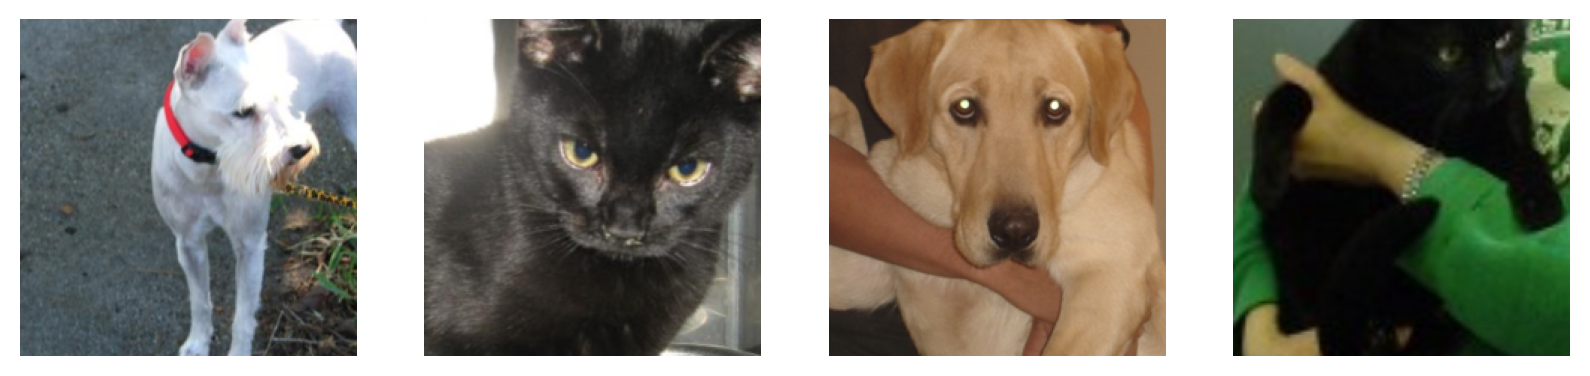

In [3]:
# change this to the trainloader or testloader 
data_iter = iter(testloader)

images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    helper.imshow(images[ii], ax=ax, normalize=False)

Your transformed images should look something like this.

<center>Training examples:</center>
<img src='./assets/train_examples.png' width=500px>

<center>Testing examples:</center>
<img src='./assets/test_examples.png' width=500px>

At this point you should be able to load data for training and testing. Now, you should try building a network that can classify cats vs dogs. This is quite a bit more complicated than before with the MNIST and Fashion-MNIST datasets. To be honest, you probably won't get it to work with a fully-connected network, no matter how deep. These images have three color channels and at a higher resolution (so far you've seen 28x28 images which are tiny).

In the next part, I'll show you how to use a pre-trained network to build a model that can actually solve this problem.

## Simple Image Classification Network

In [4]:
from torch import nn, optim
import torchvision
from torch.autograd import Variable
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [5]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(128 * 26 * 26, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

model = Classifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
print(model.state_dict().keys())
print(model)

odict_keys(['conv_block1.0.weight', 'conv_block1.0.bias', 'conv_block2.0.weight', 'conv_block2.0.bias', 'conv_block3.0.weight', 'conv_block3.0.bias', 'decoder.0.weight', 'decoder.0.bias', 'decoder.2.weight', 'decoder.2.bias'])
Classifier(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Linear(in_features=86528, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Training

In [7]:
device = "cuda" 
model.to(device)

import time

since = time.time()

n_total_steps = len(trainloader)
epochs = 6

model.train()
for epoch in range(epochs):
    running_loss = 0.0
    running_correct = 0.0
    batch = 0
    
    for images, labels in trainloader:
        batch += 1
        images = images.to(device)
        labels = labels.to(device)

        y_pred = model(images)
                
        _,pred = torch.max(y_pred.data, 1)
        loss = criterion(y_pred, labels)

        optimizer.zero_grad()
        
        loss.backward()

        optimizer.step()
        
        running_loss += loss.item()
        running_correct += torch.sum(pred == labels.data)
        accuracy = running_correct/(batch*BATCH_SIZE)

        if batch % 100 == 0:
            print(f"Epoch {epoch + 1}, Step [{batch+1}/{n_total_steps}], Loss = {running_loss/batch:.6f}, accuracy = {accuracy:.6f}")
        
print('Finished Training')

now_time = time.time() - since
print("Training time is:{:.0f}m {:.0f}s".format(now_time//60, now_time%60))


Epoch 1, Step [101/625], Loss = 0.709675, accuracy = 0.535000
Epoch 1, Step [201/625], Loss = 0.700428, accuracy = 0.534531
Epoch 1, Step [301/625], Loss = 0.696461, accuracy = 0.534479
Epoch 1, Step [401/625], Loss = 0.693753, accuracy = 0.539609
Epoch 1, Step [501/625], Loss = 0.690651, accuracy = 0.545250
Epoch 1, Step [601/625], Loss = 0.687104, accuracy = 0.553177
Epoch 2, Step [101/625], Loss = 0.648882, accuracy = 0.617500
Epoch 2, Step [201/625], Loss = 0.650512, accuracy = 0.612031
Epoch 2, Step [301/625], Loss = 0.646174, accuracy = 0.620417
Epoch 2, Step [401/625], Loss = 0.640620, accuracy = 0.625156
Epoch 2, Step [501/625], Loss = 0.638858, accuracy = 0.627813
Epoch 2, Step [601/625], Loss = 0.637723, accuracy = 0.629063
Epoch 3, Step [101/625], Loss = 0.626224, accuracy = 0.654687
Epoch 3, Step [201/625], Loss = 0.618385, accuracy = 0.660312
Epoch 3, Step [301/625], Loss = 0.613211, accuracy = 0.663438
Epoch 3, Step [401/625], Loss = 0.608493, accuracy = 0.668359
Epoch 3,

## Validation

In [8]:
device = "cuda"
model.to(device)
model.eval()

start = time.time()
classes = test_data.classes

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0, 0]
    n_class_samples = [0, 0]

    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, pred = torch.max(outputs, 1)

        n_samples += labels.size(0)
        n_correct += (pred == labels).sum().item()

        for i in range(len(labels)):
            label = labels[i].item()
            predicted = pred[i].item()

            if label == predicted:
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc:.2f} %')

    for i in range(2):
        acc = 100.0 * n_class_correct[i] / n_class_samples[i]
        print(f'Accuracy of {classes[i]}: {acc:.2f} %')

    print(f'Image count: {sum(n_class_samples)} pcs')

print(f"Device = {device}; Time per batch: {(time.time() - start)/len(testloader):.3f} seconds")

/usr/local/lib64/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Accuracy of the network: 77.00 %
Accuracy of Cat: 75.32 %
Accuracy of Dog: 78.68 %
Image count: 5000 pcs
Device = cuda; Time per batch: 0.905 seconds
